In [153]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import subprocess
from tqdm import tqdm_notebook
import pprint
import librosa
from IPython.display import clear_output
from scipy.ndimage import convolve
import music21
import madmom
from scipy.signal import convolve2d
from scipy.stats import linregress
import yaml
from multiprocessing import Pool

from msmd.midi_parser import notes_to_onsets, FPS
from msmd.data_model.piece import Piece
from msmd.alignments import align_score_to_performance

In [144]:
# path to MSMD dataset
DATA_ROOT_MSMD = '/data/mirlab/msmd/msmd_aug/msmd_aug'

In [145]:
# obtain all the pieces in the dataset
with open('/data/mirlab/msmd/msmd/msmd/splits/all_pieces.yaml', 'r') as f:
    doc = yaml.load(f)
    
pieces = doc['success']

In [146]:
def extractStrips(mungos_per_page):
    """
    Extract a list of staves' mungos objects.
    
    Input: 
        mungos_per_page - a list of mungos per page
        
    Output:
        strips - a list of (page, system_mungo, notehead_mungos) indicating each strip in sequential order.
        where 
            page = page number
            system_mungo = a mungo for a staff
            notehead_mungos = mungos for all noteheads in that page
    """
    strips = []
    
    page_num = len(mungos_per_page)
    for page in range(page_num):
        system_mungos = [c for c in mungos_per_page[page] if c.clsname == 'staff']
        system_mungos = sorted(system_mungos, key=lambda m: m.top)
        notehead_mungos = [c for c in mungos_per_page[page] if c.clsname == 'notehead-full']
        for system_mungo in system_mungos:
            strips.append((page, system_mungo, notehead_mungos))
    
    return strips

In [147]:
def convertMungoToImage(system_mungo, notehead_mungos, image, page_num,
                        marginLeftRatio=0,
                        marginRightRatio=0,
                        marginTopRatio=0.45, 
                        marginBottomRatio=0.45,
                        verbose=True):
    """
    Convert staff location information from mungo to an actual image.
    
    Input:
        system_mungo - mungo for a staff line
        notehead_mungos - mungos for noteheads
        image - an image of the page corresponding to the system_mungo
        
    Output:
        image - an image in np.array whose values are np.int8
    
    """
    
    # Get the bounding box of the staff
    (y_top, x_left, y_bottom, x_right) = system_mungo.bounding_box
    height = y_bottom - y_top
    width = x_right - x_left
    
    # Calculate the vertical margins
    marginTop = min(int(round(marginTopRatio * height)), y_top)  #  Prevent out-of-page margin
    marginBottom = min(int(round(marginBottomRatio * height)), image.shape[0] - y_bottom) #  Prevent out-of-page margin
     
    # Calculate the starting and ending vertical positions
    y_start = y_top - marginTop
    y_end = y_bottom + marginBottom
    
    # Calculate the horizontal margins
    marginLeft = min(int(round(marginLeftRatio * width)), x_left) # Prevent out-of-page margin
    marginRight = min(int(round(marginRightRatio * width)), image.shape[1] - x_right) # Prevent out-of-page margin
    
    # Calculate the starting and ending horizontal positions
    x_start = x_left - marginLeft
    x_end = x_right + marginRight
    
    # Plot noteheads
    out_mungos = {}
    for n in notehead_mungos:
        if x_start <= n.middle[1] < x_end and y_start <= n.middle[0] < y_end:
            # Add notes to the output list
            n.translate(down=-y_start, right=-x_start)
            out_mungos[n.objid] = n
            if verbose:
                plt.plot(n.middle[1] - x_start, n.middle[0] - y_start, 'bo', alpha=0.5)
    
    if verbose:
        plt.imshow(image[y_start:y_end,x_start:x_end], cmap="gray")
        plt.show()
        
    return image[y_start:y_end, x_start:x_end], out_mungos

In [148]:
def calcErrorStats(errs, tols):
    errorRates = []
    for tol in tols:
        toAdd = np.sum(np.abs(errs) >= tol) / len(errs)
        errorRates.append(toAdd)
        
    avgError = np.average(np.abs(errs))
    stdError = np.std(np.abs(errs))
    return errorRates, avgError, stdError

In [169]:
def processPiece(piece_idx, debug=False):
    piece_name = pieces[piece_idx]
    
    # Load the piece and score
    piece = Piece(root=DATA_ROOT_MSMD, name=piece_name)
    assert len(piece.available_scores) == 1
    score = piece.load_score(piece.available_scores[0])
    images = score.load_images()
    
    # Get mungos
    mungos = score.load_mungos()
    mdict = {m.objid: m for m in mungos}
    mungos_per_page = score.load_mungos(by_page=True)
    
    # Extract strips
    strips = extractStrips(mungos_per_page)
    strip_images = []
    note_mango_dict = {}
    for (strip_num, (page, system_mungo, note_mungos)) in enumerate(strips):
        strip_image, out_mungos = convertMungoToImage(system_mungo, 
                                                      note_mungos, 
                                                      images[page], 
                                                      page,
                                                      verbose=False)
        strip_images.append(strip_image)
        for n in out_mungos:
            note_mango_dict[n] = (strip_num, out_mungos[n])
    
    # Compute base x refs
    base_x_strips = [0]
    for strip_num in range(1,len(strip_images)):
        base_x_strips.append(base_x_strips[strip_num - 1] + strip_images[strip_num - 1].shape[1])
    
    # Enumerate over all performances
    output = {}
    for performance_name in piece.available_performances:        
        # Get performance path
        performance_path = os.path.join(DATA_ROOT_MSMD, piece_name, 'performances', performance_name)
        
        # Get the alignment
        performance = piece.load_performance(performance_name, require_audio=False)
        alignment = align_score_to_performance(score, performance)
        note_events = performance.load_note_events()
        
        # Get prediction
        if not os.path.exists(os.path.join(performance_path, 'output.npy')):
            continue
        prediction = np.load(os.path.join(performance_path, 'output.npy'))
        wp = prediction.item().get('wp')
        zeroPad = prediction.item().get('zeroPad')
        factor = prediction.item().get('factor')
        
        errs = []
        for alignment_idx in range(len(alignment)):
            m_objid, e_idx = alignment[alignment_idx]
            strip_num, note_object = note_mango_dict[m_objid]
            midi_event = note_events[e_idx]
        
            # given the midi note event we compute the corresponding onset frame
            dt = 1.0 / FPS
            onset_frame = int(np.ceil(midi_event[0] / dt))
        
            # gt loc
            gt_x = base_x_strips[strip_num] + note_object.middle[1]
            
            # spec_loc
            spec_x = onset_frame
            
            # rescaled_spec
            rescaled_spec_x = spec_x * factor + zeroPad
            
            # pred loc
            pred_x = np.interp(rescaled_spec_x, rescaled_spec_loc, pred_loc)
            
            if debug:
                print("gt_x = {}    spec_x = {}    resclaed_spec_x = {}   pred_x = {} err = {}".format(gt_x, 
                                                                                              spec_x, 
                                                                                              rescaled_spec_x,
                                                                                              pred_x, pred_x - gt_x))
            
            errs.append(pred_x - gt_x)
            
        
        if debug:
            tols = np.arange(100)
            errorRates, avgError, stdError = calcErrorStats(errs, tols)
            plt.plot(tols, errorRates)
            plt.grid()
            plt.xlabel("Error Tolerance (px)")
            plt.ylabel("Error Rate (pixels)")
            plt.title("Average Error = {:.2f} px (std = {:.2f})".format(avgError, stdError))
            plt.show()

        output[performance_name] = errs
    return output

In [269]:
with Pool(2) as p:
    output = list(tqdm_notebook(p.imap(processPiece, range(len(pieces[:12]))), total=len(pieces[:12])))

HBox(children=(IntProgress(value=0, max=12), HTML(value='')))

In [270]:
output_dict = {}
for piece_idx in range(len(output)):
    output_piece = {}
    for key in output[piece_idx]:
        output_piece[key] = output[piece_idx][key]
    output_dict[pieces[piece_idx]] = output_piece

In [271]:
def aggregateResult(errs_dict, tols=np.arange(100), 
                    markers=['.','v','^','x','D','h','*'],
                    debug=False):
    errs = []
    for piece in errs_dict:
        if len(errs_dict[piece]) == 0: continue
        
        piece_errs = []
        if debug:
            plt.figure()
            
        for i, performance in enumerate(errs_dict[piece]):
            piece_errs.extend(errs_dict[piece][performance])
        
            if debug:
                errorRates, avgError, stdError = calcErrorStats(errs_dict[piece][performance], tols)
                label_name = performance.split(piece)[1][1:]
                
                plt.plot(tols, errorRates, label=label_name, marker=markers[i], alpha=0.5)
                
        if debug:
            plt.grid()
            plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
            plt.xlabel("Error Tolerance (px)")
            plt.ylabel("Error Rate")
#             plt.ylim([0,1])
            plt.title("{} (avg = {:.2f}, std = {:.2f})".format(piece, avgError, stdError))
            plt.show()
    
        errs.extend(piece_errs)
    errorRates, avgError, stdError = calcErrorStats(errs, tols)
    return errorRates, avgError, stdError

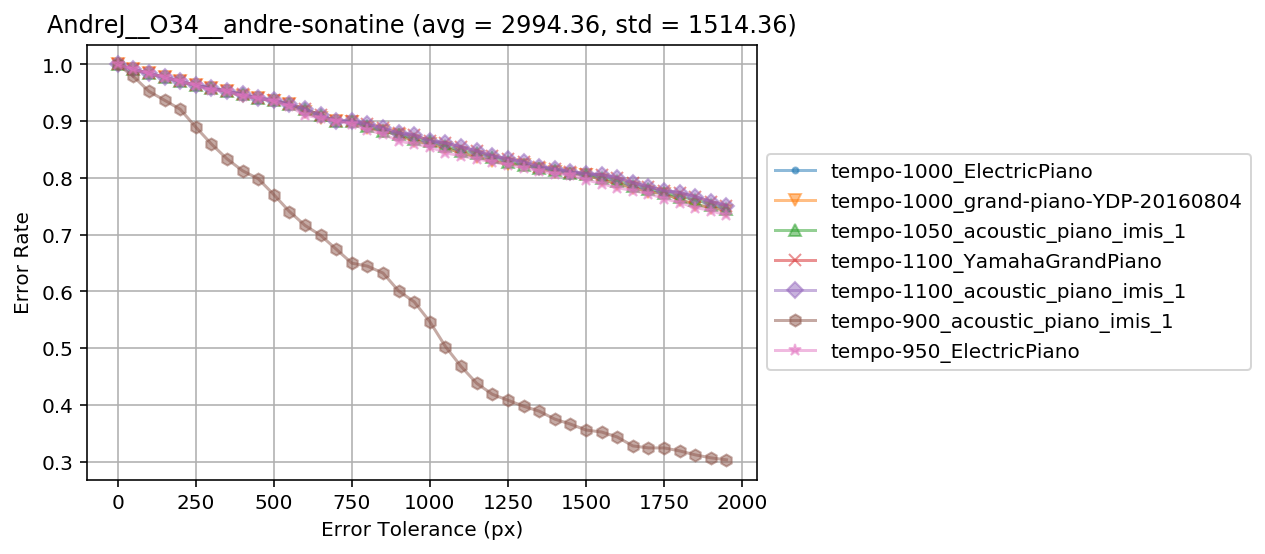

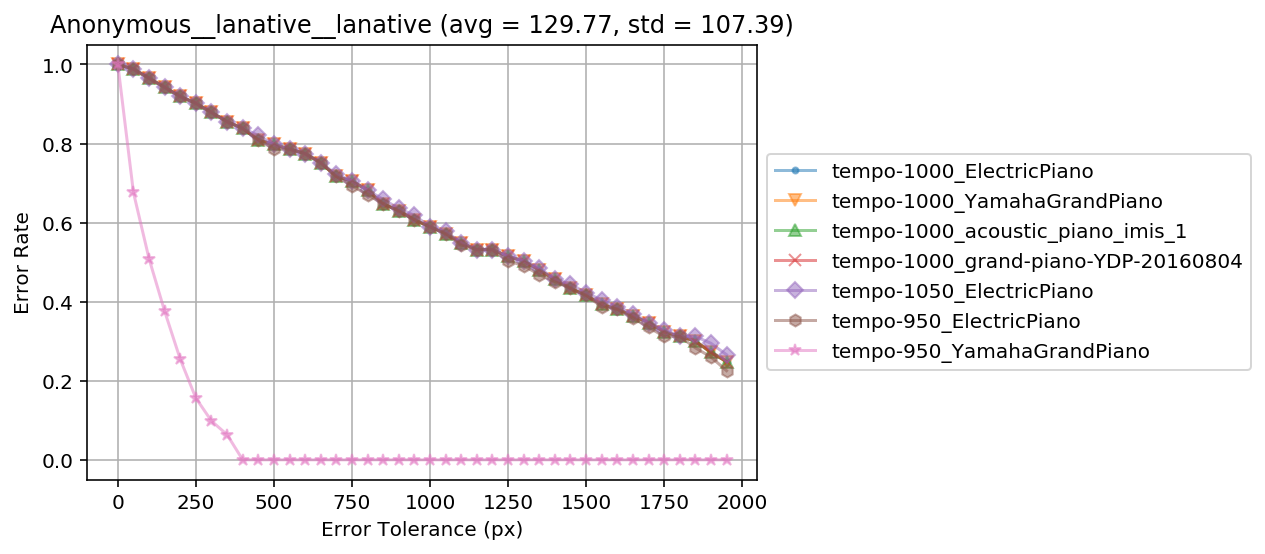

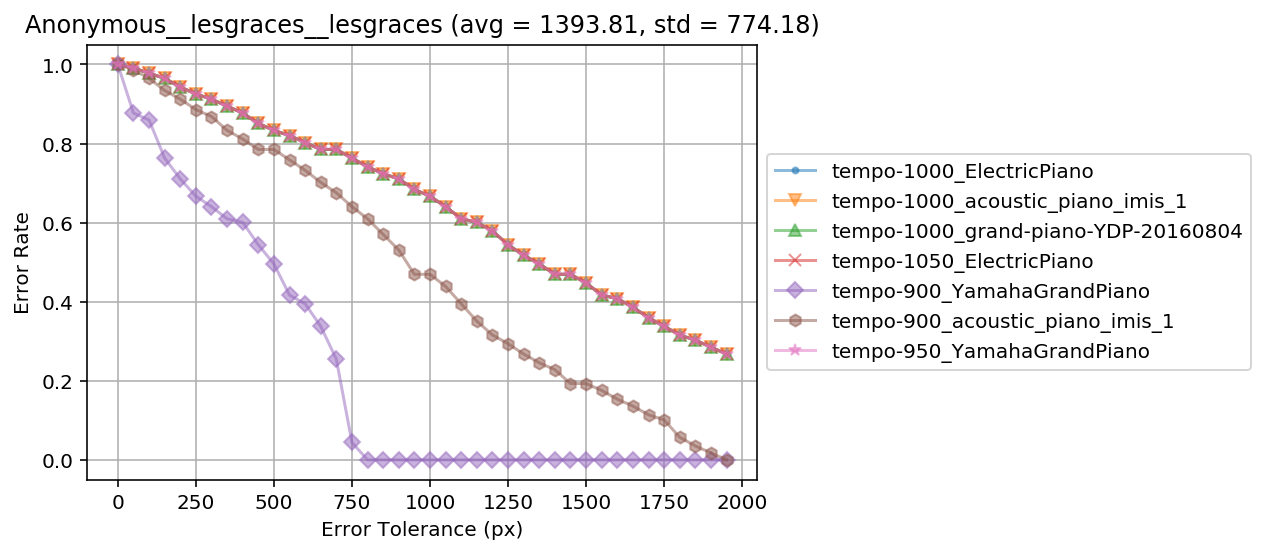

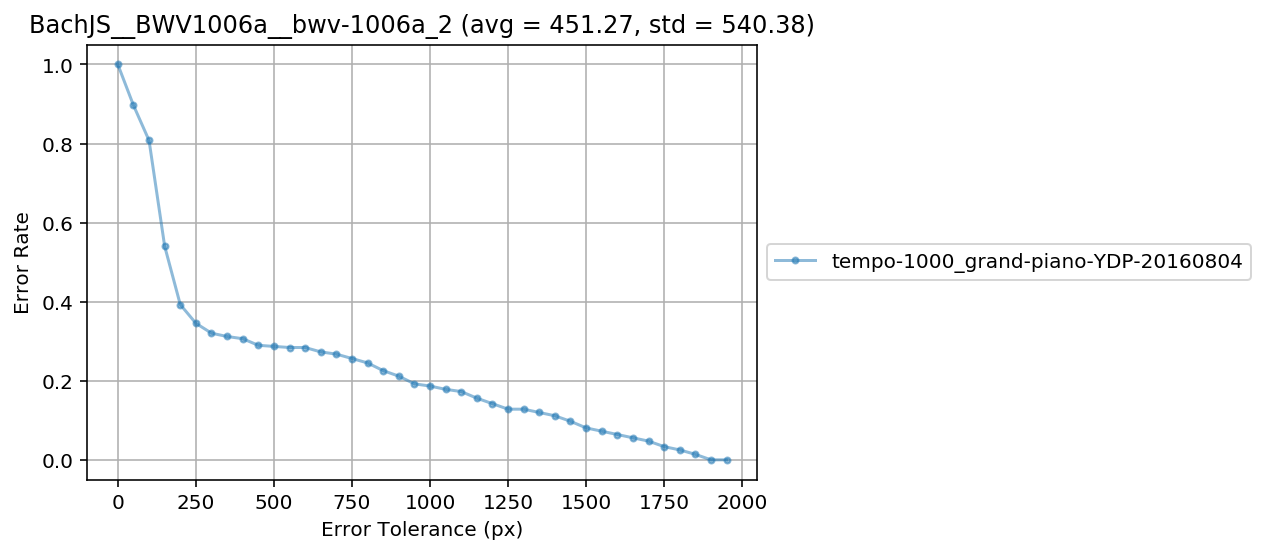

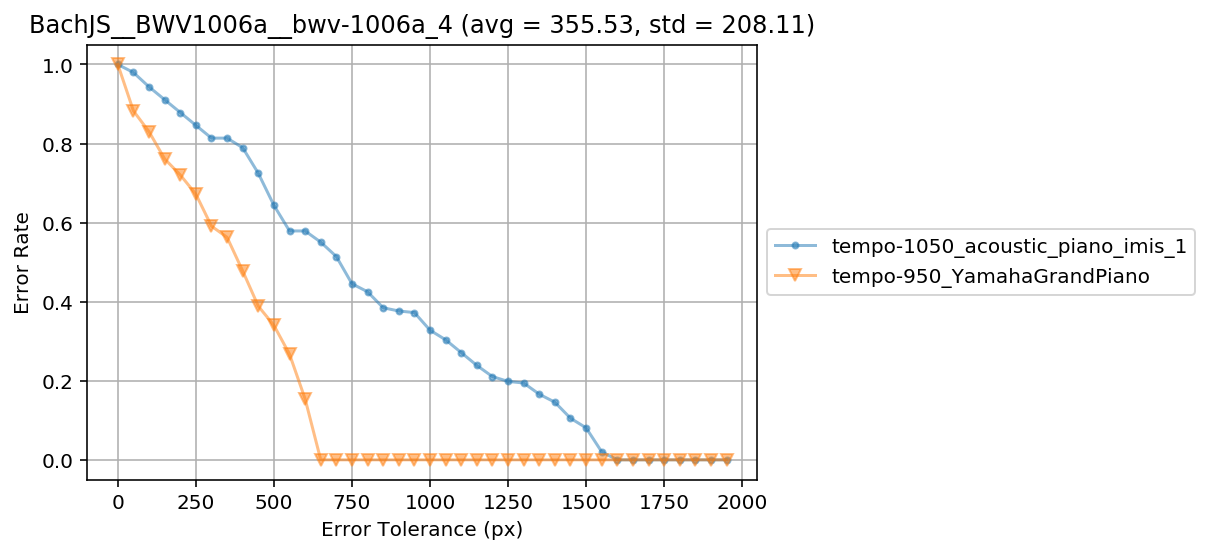

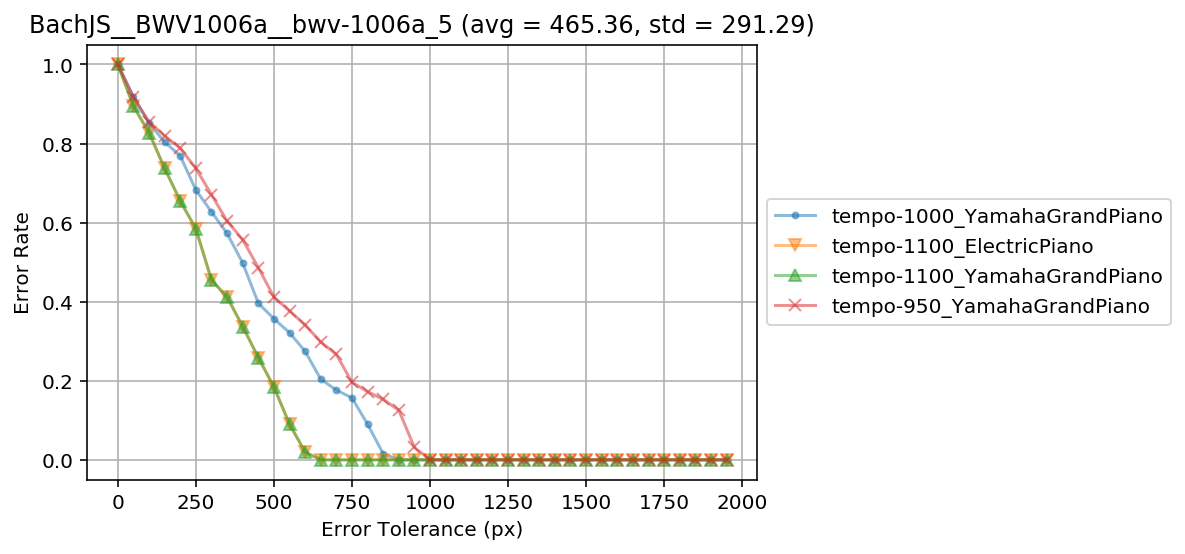

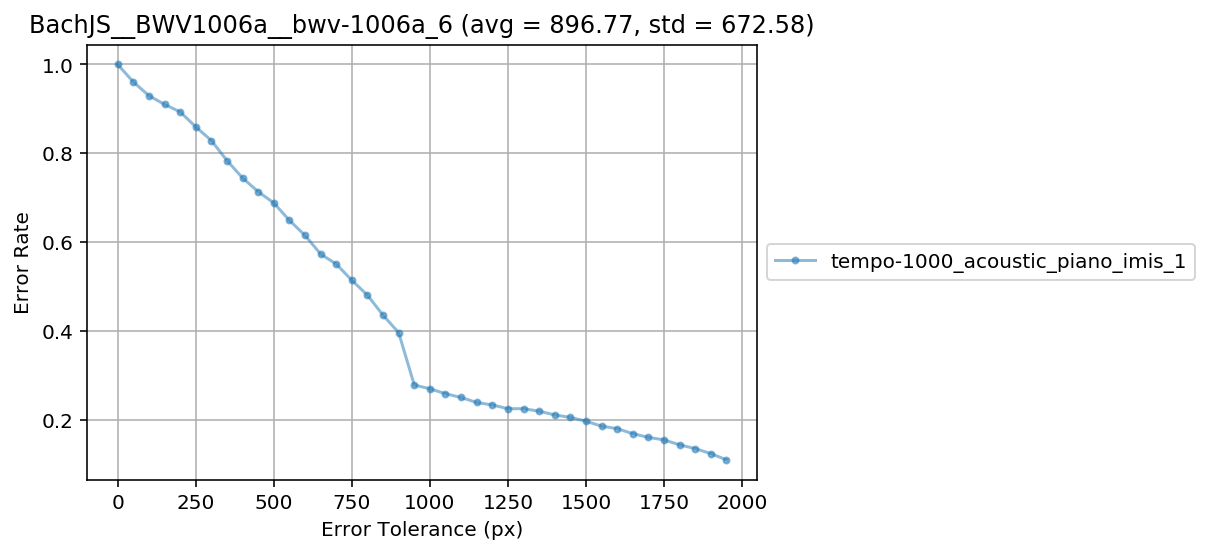

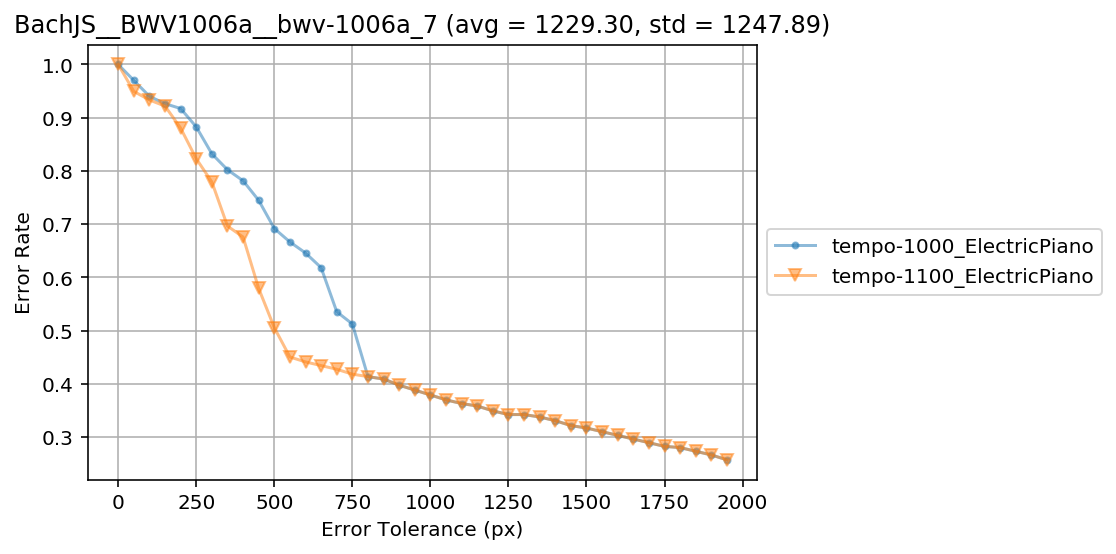

In [272]:
tols = np.arange(0,2000,50)
errorRates, avgError, stdError = aggregateResult(output_dict, tols=tols, debug=True)

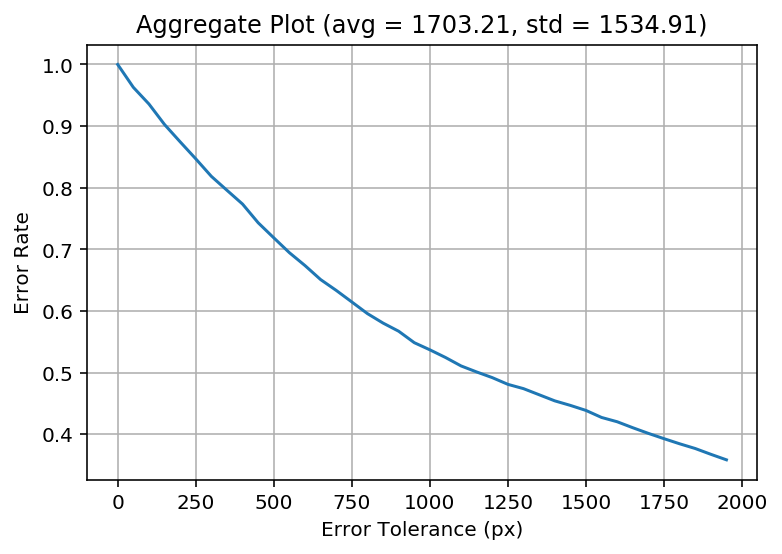

In [273]:
plt.plot(tols, errorRates)
plt.grid()
plt.xlabel("Error Tolerance (px)")
plt.ylabel("Error Rate")
plt.title("Aggregate Plot (avg = {:.2f}, std = {:.2f})".format(avgError, stdError))
plt.show()